# DQN Network Depth Ablation Study

This notebook tests how the number of hidden layers affects DQN performance on LunarLander. We train multiple agents with different `num_layers` values while keeping the other hyperparameters fixed, then compare learning curves and final performance.

**Baseline:** num_layers = 2

## 1. Setup and Imports

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import sys
import os

# Import from vanilla DQN module
sys.path.insert(0, os.path.abspath('..'))

from core.vanilla_dqn_lunar_lander import VanillaDQN, device, save_results, save_model, save_plot
from gymnasium import make

Using device: cpu


## 2. Training Function (Adapted from Vanilla)

In [2]:
def train_dqn(num_episodes=100, batch_size=32, update_frequency=4, target_update_frequency=100,
              num_layers=2, hidden_dim=128, epsilon_decay=0.995, learning_rate=1e-3,
              verbose=True):
    """Train a DQN agent on LunarLander with a configurable network depth."""

    # Create environment
    env = make('LunarLander-v3')
    state_dim = env.observation_space.shape[0]
    action_dim = env.action_space.n

    # Create agent with specified network depth
    agent = VanillaDQN(
        state_dim,
        action_dim,
        learning_rate=learning_rate,
        epsilon_decay=epsilon_decay,
        hidden_dim=hidden_dim,
        num_layers=num_layers,
    )

    # Training loop
    episode_rewards = []
    episode_losses = []
    epsilon_history = []

    for episode in range(num_episodes):
        state, _ = env.reset()
        episode_reward = 0
        episode_loss = []
        done = False
        step = 0

        while not done:
            # Select and execute action
            action = agent.select_action(state, training=True)
            next_state, reward, terminated, truncated, _ = env.step(action)
            done = terminated or truncated

            # Store transition
            agent.store_transition(state, action, reward, next_state, done)

            # Update network
            if step % update_frequency == 0:
                loss = agent.update(batch_size)
                if loss is not None:
                    episode_loss.append(loss)

            episode_reward += reward
            state = next_state
            step += 1

        # Update target network
        if (episode + 1) % target_update_frequency == 0:
            agent.update_target_network()

        # Decay epsilon
        agent.decay_epsilon()

        # Record metrics
        episode_rewards.append(episode_reward)
        epsilon_history.append(agent.epsilon)
        if episode_loss:
            episode_losses.append(np.mean(episode_loss))

        # Print progress
        if verbose and (episode + 1) % 25 == 0:
            avg_reward = np.mean(episode_rewards[-25:])
            print(
                f"  Episode {episode + 1}/{num_episodes} | "
                f"Avg Reward (last 25): {avg_reward:.2f} | "
                f"Epsilon: {agent.epsilon:.4f}"
            )

    env.close()

    return agent, episode_rewards, episode_losses, epsilon_history

## 3. Ablation Study: Test Multiple Network Depths

In [3]:
# Network depths to test. num_layers means the number of hidden Linear layers in QNetwork.
num_layer_values = [1, 2, 3, 4, 5]
num_episodes = 500

# Fixed hyperparameters for this ablation
hidden_dim = 128
learning_rate = 1e-3
epsilon_decay = 0.995
batch_size = 32
update_frequency = 4
target_update_frequency = 100

# Store results
results = {}

print("=" * 70)
print("DQN Network Depth Ablation Study")
print(f"Testing {len(num_layer_values)} network depths over {num_episodes} episodes")
print("=" * 70)

for num_layers in num_layer_values:
    print(f"\nTraining DQN with num_layers = {num_layers}")
    agent, rewards, losses, epsilon_history = train_dqn(
        num_episodes=num_episodes,
        batch_size=batch_size,
        update_frequency=update_frequency,
        target_update_frequency=target_update_frequency,
        num_layers=num_layers,
        hidden_dim=hidden_dim,
        epsilon_decay=epsilon_decay,
        learning_rate=learning_rate,
    )

    hyperparameters = {
        'learning_rate': learning_rate,
        'num_layers': num_layers,
        'hidden_dim': hidden_dim,
        'epsilon_decay': epsilon_decay,
        'batch_size': batch_size,
        'num_episodes': num_episodes,
        'update_frequency': update_frequency,
        'target_update_frequency': target_update_frequency,
    }

    # Results saved to: results/ablations/num_layers/{num_layers}/
    save_results(agent, rewards, losses, hyperparameters,
                 experiment_name='num_layers', variant_name=str(num_layers))
    save_model(agent, experiment_name='num_layers', variant_name=str(num_layers))
    save_plot(rewards, losses, experiment_name='num_layers', variant_name=str(num_layers))

    results[num_layers] = {
        'agent': agent,
        'rewards': rewards,
        'losses': losses,
        'epsilon_history': epsilon_history,
    }

print("\n" + "=" * 70)
print("Training Complete!")
print("=" * 70)

DQN Network Depth Ablation Study
Testing 5 network depths over 500 episodes

Training DQN with num_layers = 1
  Episode 25/500 | Avg Reward (last 25): -187.86 | Epsilon: 0.8822
  Episode 50/500 | Avg Reward (last 25): -159.12 | Epsilon: 0.7783
  Episode 75/500 | Avg Reward (last 25): -155.21 | Epsilon: 0.6866
  Episode 100/500 | Avg Reward (last 25): -158.80 | Epsilon: 0.6058
  Episode 125/500 | Avg Reward (last 25): -149.70 | Epsilon: 0.5344
  Episode 150/500 | Avg Reward (last 25): -130.38 | Epsilon: 0.4715
  Episode 175/500 | Avg Reward (last 25): -194.30 | Epsilon: 0.4159
  Episode 200/500 | Avg Reward (last 25): -107.79 | Epsilon: 0.3670
  Episode 225/500 | Avg Reward (last 25): -116.63 | Epsilon: 0.3237
  Episode 250/500 | Avg Reward (last 25): -86.91 | Epsilon: 0.2856
  Episode 275/500 | Avg Reward (last 25): -106.54 | Epsilon: 0.2520
  Episode 300/500 | Avg Reward (last 25): -65.99 | Epsilon: 0.2223
  Episode 325/500 | Avg Reward (last 25): -96.06 | Epsilon: 0.1961
  Episode 35

## 4. Summary Statistics

In [4]:
# Calculate summary statistics
summary_data = []

for num_layers in num_layer_values:
    rewards = results[num_layers]['rewards']
    losses = results[num_layers]['losses']

    summary_data.append({
        'Num Layers': num_layers,
        'Best Reward': max(rewards),
        'Final Avg (last 25)': np.mean(rewards[-25:]),
        'Mean Reward': np.mean(rewards),
        'Std Dev': np.std(rewards),
        'Initial Avg (first 25)': np.mean(rewards[:25]),
        'Mean Loss': np.mean(losses) if losses else np.nan,
    })

summary_df = pd.DataFrame(summary_data)
print("\n" + "=" * 70)
print("SUMMARY")
print("=" * 70)
print(summary_df.to_string(index=False))
print("=" * 70)


SUMMARY
 Num Layers  Best Reward  Final Avg (last 25)  Mean Reward    Std Dev  Initial Avg (first 25)  Mean Loss
          1   324.362030            76.269551   -91.443149 131.939074             -187.856336  37.268206
          2   262.379405           -23.159495  -127.075912 121.421779             -186.723988  29.795707
          3   300.292815            48.311619   -90.154045 145.753957             -159.943423  30.800792
          4   263.396829          -104.102545  -116.260261 141.555241             -173.586111  34.053767
          5   285.113387             9.397745  -119.236585 163.977905             -210.365244  33.878819


## 5. Visualization: Individual Training Curves

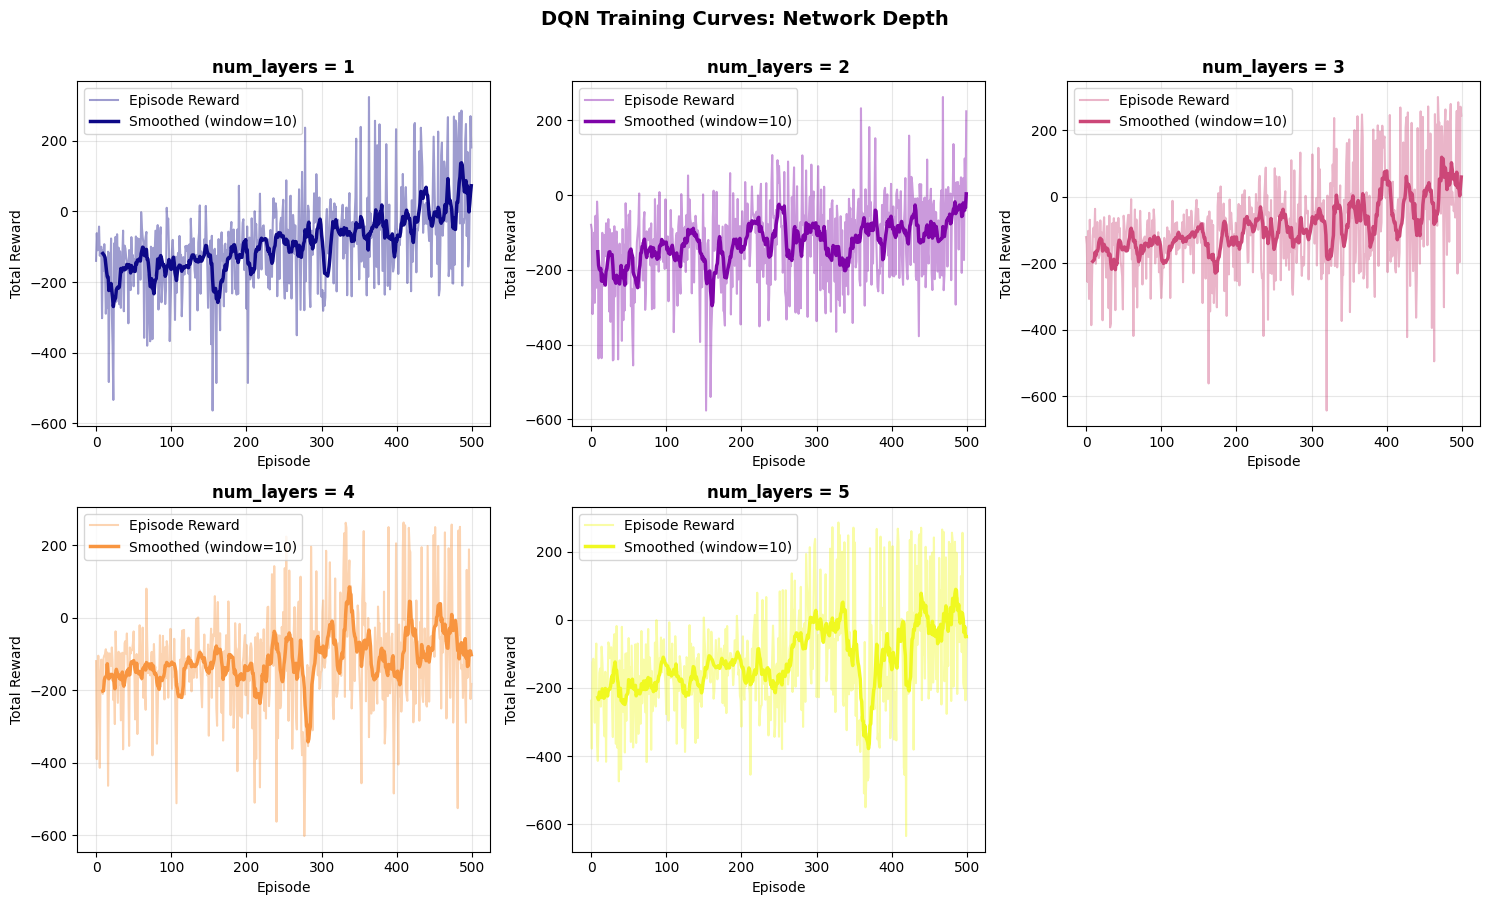

In [5]:
# Plot individual training curves for each network depth
num_values = len(num_layer_values)
cols = 3
rows = (num_values + cols - 1) // cols

fig, axes = plt.subplots(rows, cols, figsize=(cols * 5, rows * 4.5))
axes = axes.flatten()

colors = plt.cm.plasma(np.linspace(0, 1, num_values))

for idx, num_layers in enumerate(num_layer_values):
    ax = axes[idx]
    rewards = results[num_layers]['rewards']

    # Raw rewards
    ax.plot(rewards, alpha=0.4, color=colors[idx], label='Episode Reward')

    # Smoothed rewards
    window = 10
    smoothed = np.convolve(rewards, np.ones(window) / window, mode='valid')
    ax.plot(range(window - 1, len(rewards)), smoothed, color=colors[idx],
            linewidth=2.5, label=f'Smoothed (window={window})')

    ax.set_title(f'num_layers = {num_layers}', fontsize=12, fontweight='bold')
    ax.set_xlabel('Episode')
    ax.set_ylabel('Total Reward')
    ax.grid(True, alpha=0.3)
    ax.legend()

# Remove unused subplots
for empty_idx in range(num_values, len(axes)):
    fig.delaxes(axes[empty_idx])

plt.suptitle('DQN Training Curves: Network Depth', fontsize=14, fontweight='bold', y=1.00)
plt.tight_layout()
plt.show()

## 6. Visualization: Comparison of Final Performance

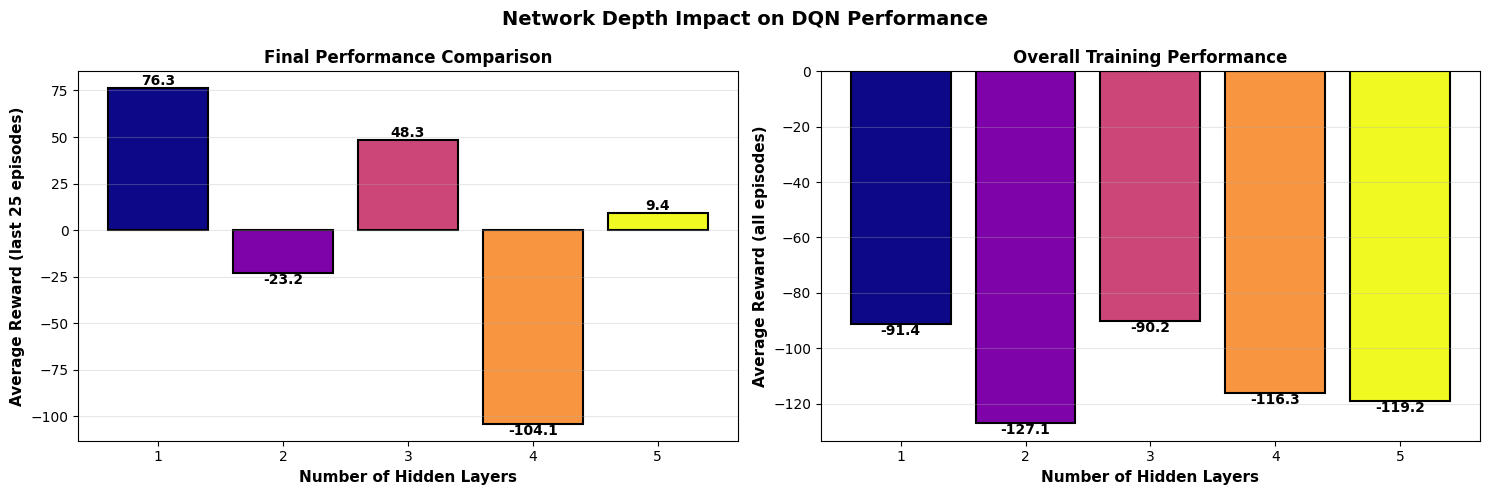

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# Plot 1: Final Average Reward
final_avgs = [np.mean(results[n]['rewards'][-25:]) for n in num_layer_values]
colors_bar = plt.cm.plasma(np.linspace(0, 1, len(num_layer_values)))

bars1 = axes[0].bar(range(len(num_layer_values)), final_avgs, color=colors_bar, edgecolor='black', linewidth=1.5)
axes[0].set_xticks(range(len(num_layer_values)))
axes[0].set_xticklabels([str(n) for n in num_layer_values])
axes[0].set_xlabel('Number of Hidden Layers', fontsize=11, fontweight='bold')
axes[0].set_ylabel('Average Reward (last 25 episodes)', fontsize=11, fontweight='bold')
axes[0].set_title('Final Performance Comparison', fontsize=12, fontweight='bold')
axes[0].grid(True, alpha=0.3, axis='y')

for bar, val in zip(bars1, final_avgs):
    height = bar.get_height()
    va = 'bottom' if height >= 0 else 'top'
    axes[0].text(bar.get_x() + bar.get_width() / 2, height,
                 f'{val:.1f}', ha='center', va=va, fontweight='bold')

# Plot 2: Mean Reward
mean_rewards = [np.mean(results[n]['rewards']) for n in num_layer_values]

bars2 = axes[1].bar(range(len(num_layer_values)), mean_rewards, color=colors_bar, edgecolor='black', linewidth=1.5)
axes[1].set_xticks(range(len(num_layer_values)))
axes[1].set_xticklabels([str(n) for n in num_layer_values])
axes[1].set_xlabel('Number of Hidden Layers', fontsize=11, fontweight='bold')
axes[1].set_ylabel('Average Reward (all episodes)', fontsize=11, fontweight='bold')
axes[1].set_title('Overall Training Performance', fontsize=12, fontweight='bold')
axes[1].grid(True, alpha=0.3, axis='y')

for bar, val in zip(bars2, mean_rewards):
    height = bar.get_height()
    va = 'bottom' if height >= 0 else 'top'
    axes[1].text(bar.get_x() + bar.get_width() / 2, height,
                 f'{val:.1f}', ha='center', va=va, fontweight='bold')

plt.suptitle('Network Depth Impact on DQN Performance', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

## 7. Visualization: Loss Curves

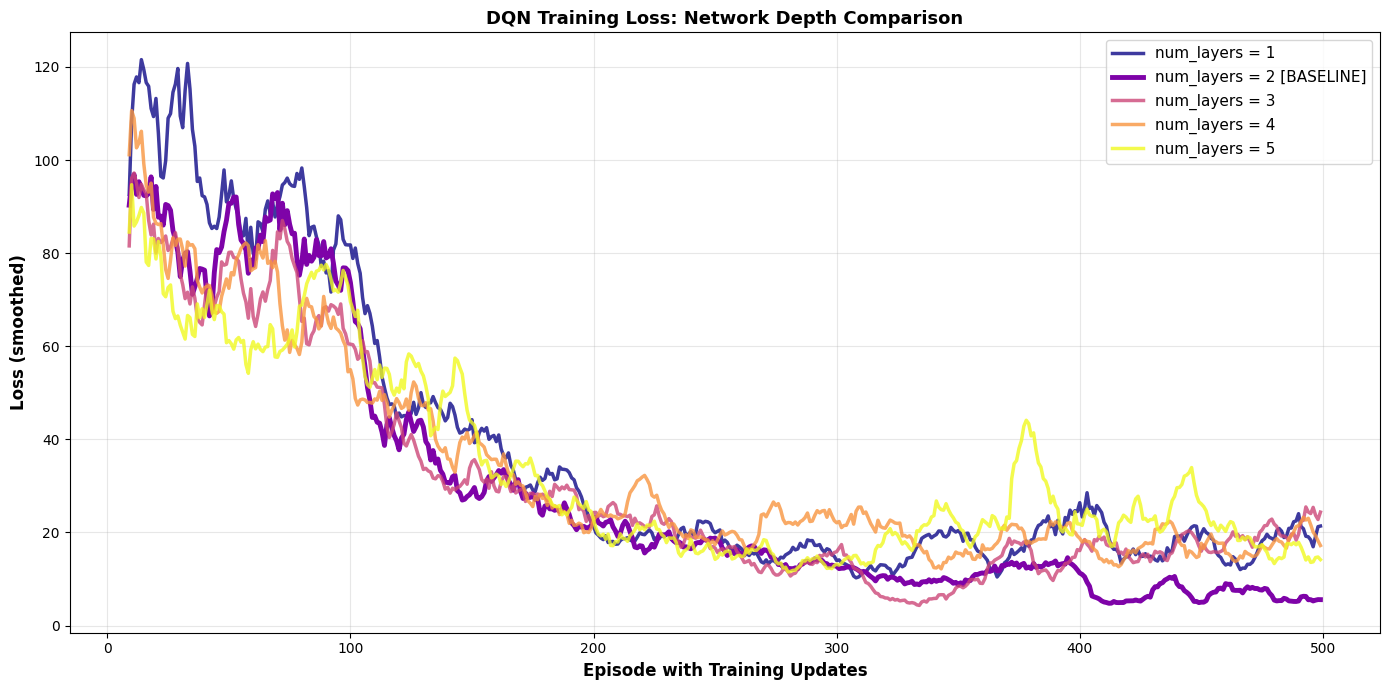

In [7]:
fig, ax = plt.subplots(figsize=(14, 7))

colors = plt.cm.plasma(np.linspace(0, 1, len(num_layer_values)))

for idx, num_layers in enumerate(num_layer_values):
    losses = results[num_layers]['losses']
    if not losses:
        continue

    window = min(10, max(1, len(losses)))
    if window > 1:
        smoothed = np.convolve(losses, np.ones(window) / window, mode='valid')
        x_values = range(window - 1, window - 1 + len(smoothed))
    else:
        smoothed = losses
        x_values = range(len(losses))

    linewidth = 3.5 if num_layers == 2 else 2.5
    alpha = 1.0 if num_layers == 2 else 0.8
    ax.plot(x_values, smoothed, linewidth=linewidth, alpha=alpha,
            label=f'num_layers = {num_layers}' + (' [BASELINE]' if num_layers == 2 else ''),
            color=colors[idx])

ax.set_xlabel('Episode with Training Updates', fontsize=12, fontweight='bold')
ax.set_ylabel('Loss (smoothed)', fontsize=12, fontweight='bold')
ax.set_title('DQN Training Loss: Network Depth Comparison', fontsize=13, fontweight='bold')
ax.legend(loc='upper right', fontsize=11)
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## 8. Visualization: Overlaid Reward Curves

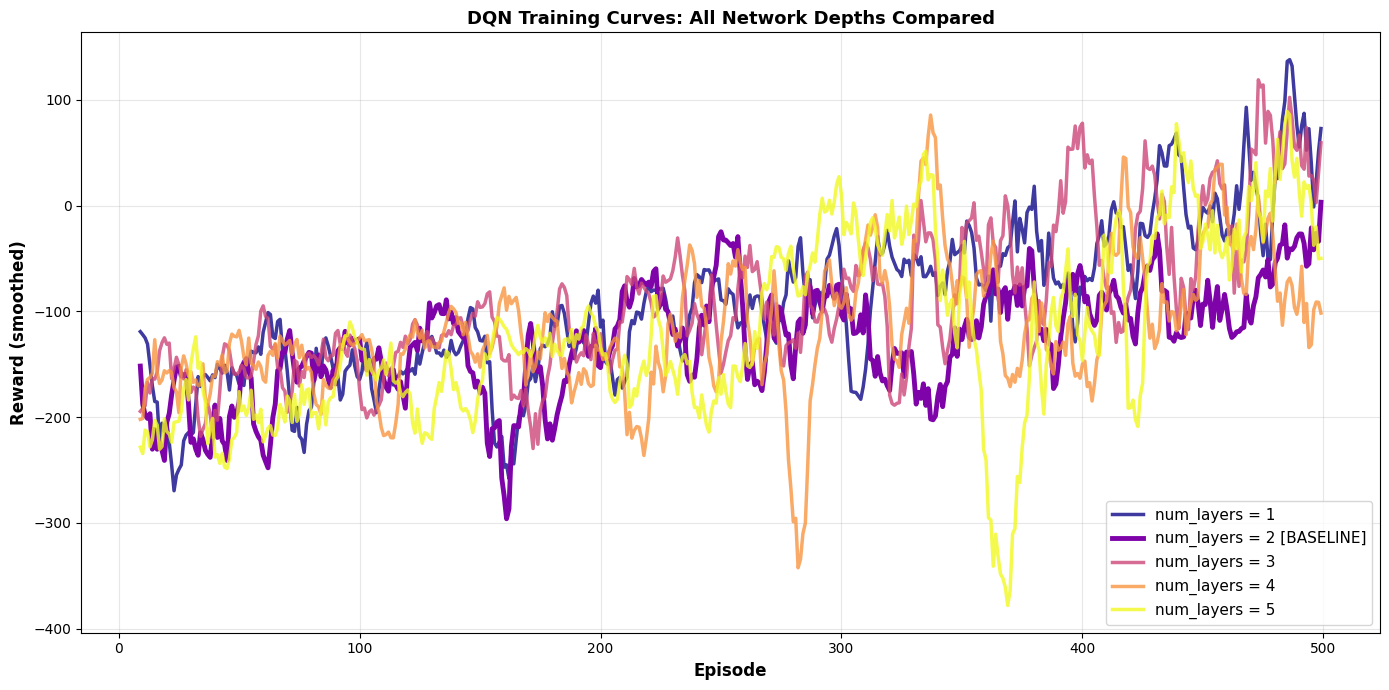

In [8]:
fig, ax = plt.subplots(figsize=(14, 7))

colors = plt.cm.plasma(np.linspace(0, 1, len(num_layer_values)))

for idx, num_layers in enumerate(num_layer_values):
    rewards = results[num_layers]['rewards']

    # Smoothed rewards
    window = 10
    smoothed = np.convolve(rewards, np.ones(window) / window, mode='valid')

    # Highlight baseline
    linewidth = 3.5 if num_layers == 2 else 2.5
    alpha = 1.0 if num_layers == 2 else 0.8

    ax.plot(range(window - 1, len(rewards)), smoothed, linewidth=linewidth,
            label=f'num_layers = {num_layers}' + (' [BASELINE]' if num_layers == 2 else ''),
            color=colors[idx], alpha=alpha)

ax.set_xlabel('Episode', fontsize=12, fontweight='bold')
ax.set_ylabel('Reward (smoothed)', fontsize=12, fontweight='bold')
ax.set_title('DQN Training Curves: All Network Depths Compared', fontsize=13, fontweight='bold')
ax.legend(loc='lower right', fontsize=11)
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## 9. Key Insights

In [9]:
# Find best performer
final_scores = [np.mean(results[n]['rewards'][-25:]) for n in num_layer_values]
best_idx = np.argmax(final_scores)
best_num_layers = num_layer_values[best_idx]
best_reward = final_scores[best_idx]

print("\n" + "=" * 70)
print("KEY FINDINGS")
print("=" * 70)
print(f"\nBest Performer: num_layers = {best_num_layers}")
print(f"  Final Average Reward (last 25 episodes): {best_reward:.2f}")

baseline_reward = np.mean(results[2]['rewards'][-25:])
print("\nBaseline (num_layers = 2):")
print(f"  Final Average Reward (last 25 episodes): {baseline_reward:.2f}")

print("\nInterpretation:")
print("  - Shallower networks have fewer parameters and may train more stably, but can underfit complex value functions.")
print("  - Deeper networks can represent more complex policies, but may be harder to optimize and less sample-efficient.")
print("  - The best depth should be judged by both final average reward and curve stability, not only the single best episode.")
print("\n" + "=" * 70)


KEY FINDINGS

Best Performer: num_layers = 1
  Final Average Reward (last 25 episodes): 76.27

Baseline (num_layers = 2):
  Final Average Reward (last 25 episodes): -23.16

Interpretation:
  - Shallower networks have fewer parameters and may train more stably, but can underfit complex value functions.
  - Deeper networks can represent more complex policies, but may be harder to optimize and less sample-efficient.
  - The best depth should be judged by both final average reward and curve stability, not only the single best episode.



## 10. Objective Evaluation of This Run

Based on this 500-episode run, the best final performer is the 1-layer network, with a final average reward of **76.27** over the last 25 episodes. The 3-layer network is the next strongest result, with **48.31**. The 5-layer network ends close to neutral at **9.40**, while the 2-layer baseline and 4-layer model finish below zero at **-23.16** and **-104.10** respectively.

| Num Layers | Best Reward | Final Avg (last 25) | Mean Reward | Std Dev | Mean Loss |
|---:|---:|---:|---:|---:|---:|
| 1 | 324.36 | 76.27 | -91.44 | 131.94 | 37.27 |
| 2 | 262.38 | -23.16 | -127.08 | 121.42 | 29.80 |
| 3 | 300.29 | 48.31 | -90.15 | 145.75 | 30.80 |
| 4 | 263.40 | -104.10 | -116.26 | 141.56 | 34.05 |
| 5 | 285.11 | 9.40 | -119.24 | 163.98 | 33.88 |

The overall conclusion is that increasing network depth did **not** consistently improve performance in this experiment. The shallow 1-layer model performed best at the end of training, suggesting that the LunarLander value function can be learned reasonably well with a smaller network under the current training setup. Deeper networks sometimes reached high individual rewards, but their learning curves were less stable and did not translate into better final averages.

However, this result should be treated as preliminary rather than definitive. Each depth was tested with only one training run, and DQN on LunarLander has high variance due to random initialization, exploration, and environment stochasticity. Also, none of the models reached the project goal of an average reward above 200, so the comparison shows relative performance under this setup, not a solved-agent comparison. A stronger evaluation would repeat each depth across several random seeds and compare the mean and standard deviation of final 100-episode returns.